In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import xarray as xr
import harmonica as hm

In [2]:
#Primeiro importamos os dados que baixamos no site do ICGEM
malha = hm.load_icgem_gdf(
    fname="../ep-3/topography_shm_etopo1-2250_62e82f5af0f79fcf0be75535b4c2da34b567809b823ceec384ff5c62179b62b0.gdf"
)
malha

<xarray.Dataset> Size: 94kB
Dimensions:         (latitude: 76, longitude: 151)
Coordinates:
  * latitude        (latitude) float64 608B -60.0 -59.0 -58.0 ... 13.0 14.0 15.0
  * longitude       (longitude) float64 1kB -95.0 -94.0 -93.0 ... 53.0 54.0 55.0
Data variables:
    topography_shm  (latitude, longitude) float64 92kB -4.965e+03 ... -2.373e+03
Attributes: (12/28)
    generating_institute:  gfz-potsdam
    generating_date:       2026/09/18
    product_type:          topography
    body:                  earth
    modelname:             etopo1
    max_used_degree:       2250
    ...                    ...
    maxvalue:              5.1208980E+03 meter
    minvalue:              -7.5776088E+03 meter
    signal_wrms:           2.3985726E+03 meter
    grid_format:           long_lat_value
    attributes:            longitude latitude topography_shm
    attributes_units:      deg. deg. meter

In [3]:
df = (
    malha["topography_shm"]
    .to_dataframe()
    .reset_index()
    .drop_duplicates(subset="topography_shm")
)

latitude = df["latitude"].values
longitude = df["longitude"].values
topografia = df["topography_shm"].values / 1000 # m para km

print(latitude.shape, longitude.shape, topografia.shape)

(11476,) (11476,) (11476,)


In [4]:
# Definimos valores de densidade para a crosta, manto e água
rhoc = 2.67 # Crosta g/cm3
rhom = 3.30 # Manto g/cm3
rhow = 1.03 # Água g/cm3

In [5]:
# Modelo de Pratt
# Definimos uma profundidade de compensação
D = 30.0 #km
# Criamos um vetor para armanezar as densidades
rho_pratt = np.zeros_like(topografia)
# Continente
continente = topografia > 0 
h = topografia[continente]
rho_pratt[continente] = (rhoc * D) / (D + h)
# Oceano 
oceano = topografia < 0 
d = - topografia[oceano]
rho_pratt[oceano] = (rhoc * D - rhow * d) / (D - d)


Text(0.5, 1.0, 'Densidade modelo de Pratt')

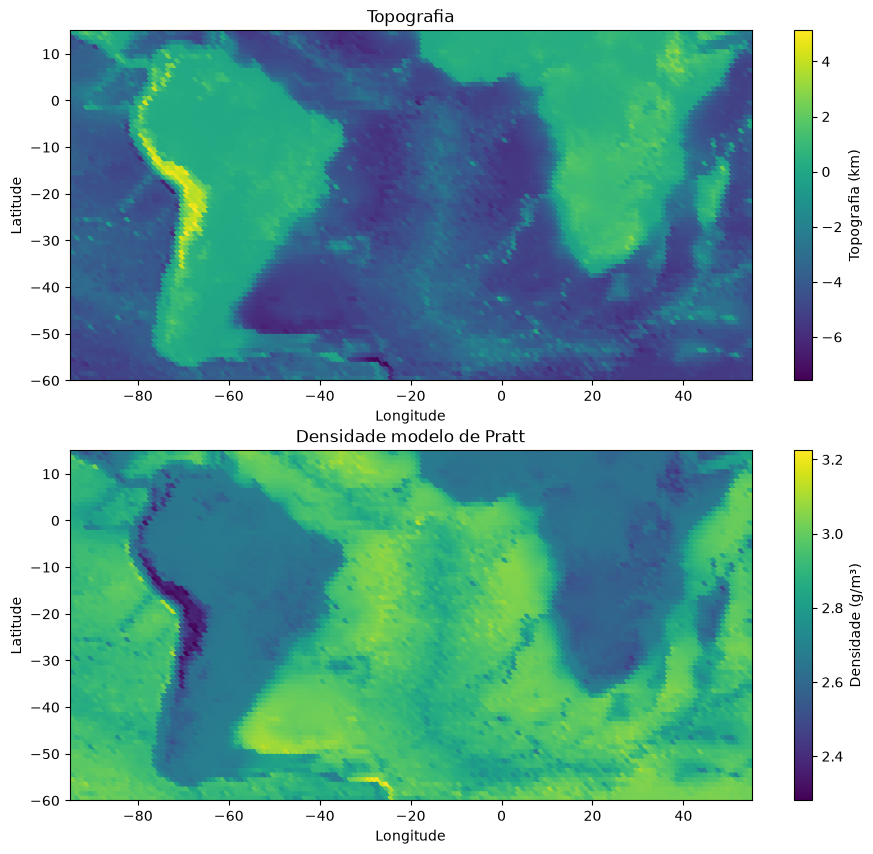

In [6]:
# Vamos plotar esses dados
plt.figure(figsize=(11,10))
# Topografia 
plt.subplot(2, 1 ,1)
plt.scatter(longitude, latitude, c = topografia)
plt.colorbar(label = 'Topografia (km)')
plt.xlim(longitude.min(), longitude.max())
plt.ylim(latitude.min(), latitude.max())
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Topografia")
# Espessura crustal 
plt.subplot(2, 1 ,2)
plt.scatter(longitude, latitude, c = rho_pratt)
plt.colorbar(label = 'Densidade (g/m³)')
plt.xlim(longitude.min(), longitude.max())
plt.ylim(latitude.min(), latitude.max())
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Densidade modelo de Pratt")

In [7]:
# 
G = 6.67430e-11 # m³/kg s²
efeito_topo = np.zeros_like(topografia)
# No continente
efeito_topo[continente] = 2 * np.pi * G * (rhoc * 1000) * (h * 1000)
# No oceano
efeito_topo[oceano] = 2 * np.pi * G * ((rhow- rhoc) * 1000) * (d * 1000)
# m/s para mGal
efeito_topo *= 1e5

Text(0.5, 1.0, 'Efeito gravitacional da topografia')

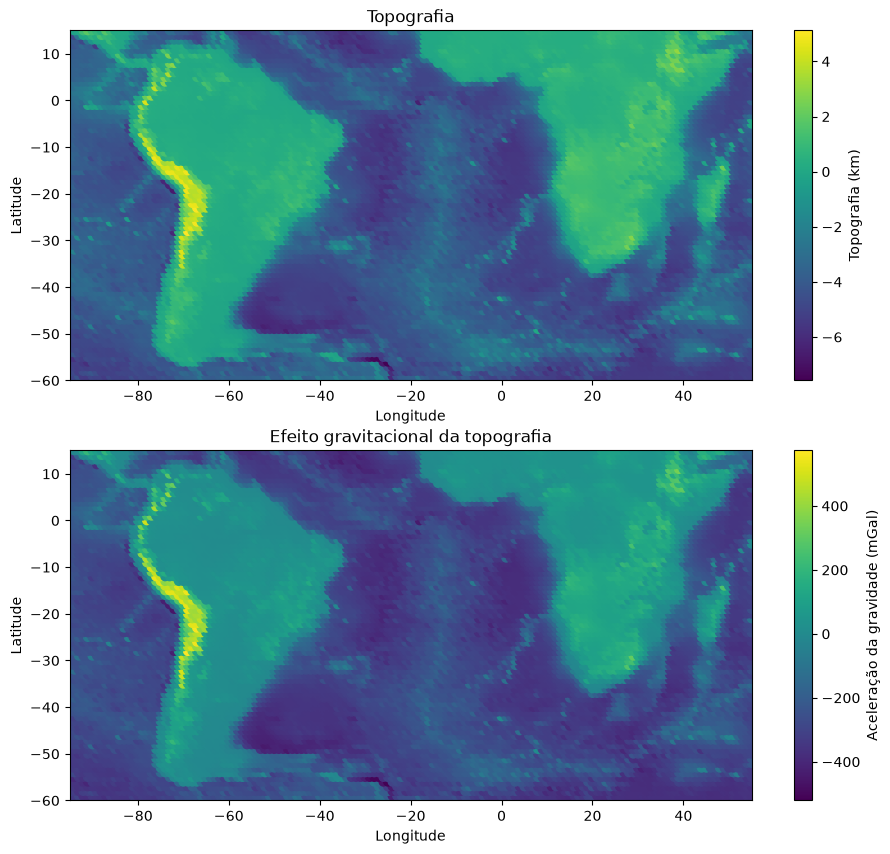

In [8]:
# Vamos plotar esses dados
plt.figure(figsize=(11,10))
# Topografia 
plt.subplot(2, 1 ,1)
plt.scatter(longitude, latitude, c = topografia)
plt.colorbar(label = 'Topografia (km)')
plt.xlim(longitude.min(), longitude.max())
plt.ylim(latitude.min(), latitude.max())
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Topografia")
# Espessura crustal 
plt.subplot(2, 1 ,2)
plt.scatter(longitude, latitude, c = efeito_topo)
plt.colorbar(label = 'Aceleração da gravidade (mGal)')
plt.xlim(longitude.min(), longitude.max())
plt.ylim(latitude.min(), latitude.max())
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Efeito gravitacional da topografia")